In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd ..

/Users/leonmac/Codes/BO-Set


In [3]:
import os
import torch
import pandas as pd
import matplotlib
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy
import multiprocessing
from itertools import product
from publib import set_style, fix_style
set_style(['article'])  

matplotlib.rcParams.update({'font.size': 22})
#plt.rcParams['text.usetex'] = True
#matplotlib.rcParams.update(matplotlib.rcParamsDefault)


supported_labels = ["random", "local_search", "dfs", "bfs", 
                    "polynomial","polynomial_suminverse","diffusion","diffusion_ard"]
# cycler('color', ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']))

d_color = {"polynomial":"#1f77b4", "diffusion_ard":"#8c564b", 
           "polynomial_suminverse":"#e377c2", "diffusion":"#7f7f7f",
           "random":"#ff7f0e", "local_search":"#2ca02c", "dfs": "#d62728", "bfs": "#9467bd"} 
d_label = {"polynomial":"BO_Poly", "polynomial_suminverse":"BO_SumInverse", 
           "diffusion_ard":"BO_Diff_ARD", "diffusion":"BO_Diff", 
           "random":"Random", "local_search":"Local search", "dfs": "Dfs", "bfs": "Bfs"}

title_font=30
my_font=28
tick_font=25
xlim=150

In [4]:
def plot_result(ax, path: str, label: str, plot_kwargs: dict = None, median=False,
                std=False, cumulative=True, regret=True, minimization=False, xlim=None):
    # path: main directory of experiments (eg. logs/centrality), label : label experiment to plot
    exp_dir = os.path.join(path, label)
    algorithm_name = [name for name in os.listdir(exp_dir) if os.path.isdir(os.path.join(exp_dir, name))]
    if len(algorithm_name) == 8:
        algorithm_name=['local_search', 'dfs', 'bfs', 'random',
                        'diffusion', 'diffusion_ard', 'polynomial_suminverse', 'polynomial']
    min_max_len = np.inf
    tick_size = 25
    my_font = 28
    for algorithm in algorithm_name:
        alg_dir = os.path.join(exp_dir, algorithm)
        ## Here are in directory with signal png and pt
        plot_kwargs = deepcopy(plot_kwargs) or {}
        data_path_seeds = [f for f in os.listdir(alg_dir) if ".pt" in f]
        data_over_seeds = []
        for i, df in enumerate(data_path_seeds):
            data_path = os.path.join(alg_dir, df)
            with open(data_path, "rb") as fp:
                data = torch.load(data_path, map_location="cpu")
                minimize = False
            if "regret" in data.keys() and regret:
                y = -data["regret"].numpy().flatten()   # to maximize negative regret
                minimize = True
            else:
                assert "Y" in data.keys()
                y = data["Y"].numpy().flatten()
            if minimization:
                minimize = True
            data_over_seeds.append(y)
        n_data_per_trial = np.array([len(d) for d in data_over_seeds])
        max_len = max(n_data_per_trial)
        if len(np.unique(n_data_per_trial)) > 1:
            # pad as appropriate
            for i, d in enumerate(data_over_seeds):
                data_over_seeds[i] = np.concatenate((
                    d, d[-1] * np.ones(max_len - d.shape[0])))
        all_data = np.array(data_over_seeds)
        if cumulative:
            y = pd.DataFrame(all_data).cummax(axis=1)
        else:
            y = pd.DataFrame(all_data)
        x = np.arange(all_data.shape[1])
        if median:
            mean = y.median(axis=0)
            lb = y.quantile(q=0.25, axis=0)
            ub = y.quantile(q=0.75, axis=0)
        elif std:
            mean = y.mean(axis=0)
            # standard error
            lb = mean - y.std(axis=0)
            ub = mean + y.std(axis=0)
        else:
            mean = y.mean(axis=0)
            # standard error
            lb = mean - y.std(axis=0) / np.sqrt(all_data.shape[0])
            ub = mean + y.std(axis=0) / np.sqrt(all_data.shape[0])
        if minimize:
            mean = -mean
            lb = -lb
            ub = -ub
        ax.plot(x[:xlim+1], mean[:xlim+1], ".-", label=d_label[algorithm], color=d_color[algorithm], **plot_kwargs)
        if "alpha" in plot_kwargs.keys():
            del plot_kwargs["alpha"]
        if "markevery" in plot_kwargs.keys():
            del plot_kwargs["markevery"]
        ax.fill_between(x[:xlim+1], lb[:xlim+1], ub[:xlim+1], alpha=0.1, color=d_color[algorithm], **plot_kwargs)
        ax.plot(x[:xlim+1], lb[:xlim+1], "-", alpha=0.2, color=d_color[algorithm], **plot_kwargs)
        ax.plot(x[:xlim+1], ub[:xlim+1], "-", alpha=0.2, color=d_color[algorithm], **plot_kwargs)
        min_max_len = min(min_max_len, max_len)
    #ax.legend()
    #ax.set_xlabel("\#Iters", fontsize=my_font)
    #ax.set_ylabel("Regret", fontsize=my_font)
    ax.tick_params(axis='both', labelsize=tick_size)
    #ax.set_xlim([0, min_max_len])
    ax.set_xlim([0, xlim])
    #ax.grid()
    #plt.yscale("log")
    
    #plt.savefig(os.path.join(exp_dir, "plot_result_regretpng.png"), bbox_inches='tight')
    #plt.savefig(os.path.join(exp_dir, "plot_result_regretpdf.pdf"), bbox_inches='tight')
    #plt.clf()
    #return y, max_len

# BA Graph Centrality

In [5]:
def plot_ba(failtol, Q):
    save_path = f'experiment_figs/Synthetic/failtol-{failtol}_Q-{Q}/'
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    list_experiences = [f"ba_eigenvector_centrality_n-1000_k-2_m-2_ninit-10_failtol-{failtol}_Q-{Q}_query-500", 
                        f"ba_eigenvector_centrality_n-1000_k-3_m-2_ninit-10_failtol-{failtol}_Q-{Q}_query-500",
                        f"ba_eigenvector_centrality_n-1000_k-4_m-2_ninit-10_failtol-{failtol}_Q-{Q}_query-500",
                        f"ba_eigenvector_centrality_n-1000_k-2_m-3_ninit-10_failtol-{failtol}_Q-{Q}_query-500",
                        f"ba_eigenvector_centrality_n-1000_k-3_m-3_ninit-10_failtol-{failtol}_Q-{Q}_query-500",
                        f"ba_eigenvector_centrality_n-1000_k-4_m-3_ninit-10_failtol-{failtol}_Q-{Q}_query-500",]
    n_rows, n_cols = 2, 3
    title_font=30
    #fig, axs = plt.subplots(n_rows, n_cols, layout='constrained', figsize=(20, 8))
    fig, axs = plt.subplots(n_rows, n_cols, layout='constrained', figsize=(24, 10))
    for i, experience in enumerate(list_experiences):
        idx_row, idx_col = i // n_cols, i % n_cols
        #print(idx_row, idx_col)

        plot_result(axs[idx_row, idx_col], "./logs/testing/", list_experiences[i], std=True, xlim=500)

    handles, labels = axs[idx_row, idx_col].get_legend_handles_labels()
    change_labels = [0, 1, 5, 7, 2, 3, 6, 4 ]
    labels = [labels[i] for i in change_labels]
    handles = [handles[i] for i in change_labels]

    axs[0, 0].set_title(r'(a) $m = 2$; ' + r'$k = 2$', fontsize=title_font)
    #axs[0, 0].text(20, 0.5 , r'$sm=21$')
    axs[0, 0].set_ylabel("Regret", fontsize=my_font)
    axs[0, 1].set_title(r'(b) $m = 2$; ' + r'$k = 3$', fontsize=title_font)
    #axs[0, 1].text(20, 0.17, r'$sm=33$')
    axs[0, 2].set_title(r'(c) $m = 2$; ' + r'$k = 4$', fontsize=title_font)
    #axs[0, 2].text(20, 0.11, r'$sm=51$')

    
    
    axs[1, 0].set_title(r'(d) $m = 3$; ' + r'$k = 2$', fontsize=title_font)
    #axs[1, 0].text(20, 0.35, r'$sm=25$')
    axs[1, 0].set_ylabel("Regret", fontsize=my_font)
    axs[1, 0].set_xlabel("#Queries", fontsize=my_font)
    
    axs[1, 1].set_title(r'(e) $m = 3$; ' + r'$k = 3$', fontsize=title_font)
    #axs[1, 1].text(20, 0.32, r'$sm=34$')
    axs[1, 1].set_xlabel("#Queries", fontsize=my_font)
    
    axs[1, 2].set_title(r'(f) $m = 3$; ' + r'$k = 4$', fontsize=title_font)
    #axs[1, 2].text(20, 0.26, r'$sm=48$')
    axs[1, 2].set_xlabel("#Queries", fontsize=my_font)


    fig.legend(handles = handles, labels=labels, loc='upper center', bbox_to_anchor=(0.5, 0.), 
               frameon=True, fancybox=False, shadow=False, ncol=8, fontsize=tick_font-2)

    fix_style('article')
    plt.tight_layout()
    plt.savefig(f"{save_path}centrality_ba.pdf", bbox_inches='tight')
    plt.savefig(f"{save_path}centrality_ba.png", bbox_inches='tight')

    #plt.show()

# WS Graph Centrality

In [6]:
def plot_ws(failtol, Q):
    title_font=28
    save_path = f'experiment_figs/Synthetic/failtol-{failtol}_Q-{Q}/'
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    list_experiences = [f"ws_betweenness_centrality_n-5000_k-2_wsk-10_p-0.1_ninit-10_failtol-{failtol}_Q-{Q}_query-1000",
                        f"ws_betweenness_centrality_n-5000_k-3_wsk-10_p-0.1_ninit-10_failtol-{failtol}_Q-{Q}_query-1000",
                        f"ws_betweenness_centrality_n-5000_k-4_wsk-10_p-0.1_ninit-10_failtol-{failtol}_Q-{Q}_query-1000",
                        f"ws_betweenness_centrality_n-5000_k-2_wsk-30_p-0.2_ninit-10_failtol-{failtol}_Q-{Q}_query-1000",
                        f"ws_betweenness_centrality_n-5000_k-3_wsk-30_p-0.2_ninit-10_failtol-{failtol}_Q-{Q}_query-1000",
                        f"ws_betweenness_centrality_n-5000_k-4_wsk-30_p-0.2_ninit-10_failtol-{failtol}_Q-{Q}_query-1000",
                       ]
    n_rows, n_cols = 2, 3
    fig, axs = plt.subplots(n_rows, n_cols, layout='constrained', figsize=(24, 10))
    for i, experience in enumerate(list_experiences):
        idx_row, idx_col = i // n_cols, i % n_cols
        #print(idx_row, idx_col)
        try:
            plot_result(axs[idx_row, idx_col], "./logs/testing/", list_experiences[i], 
                        std=True, xlim=1000)
        except:
            pass
    handles, labels = axs[idx_row, idx_col].get_legend_handles_labels()
    change_labels = [0, 1, 5, 7, 2, 3, 6, 4 ]
    labels = [labels[i] for i in change_labels]
    handles = [handles[i] for i in change_labels]

    axs[0, 0].set_title(r'(a) $(k,p)=(10,0.1)$; ' + r'$k=2$', fontsize=title_font)
    axs[0, 0].set_yscale("log") 
    axs[0, 0].set_ylabel("Regret", fontsize=my_font)
    #axs[0, 0].text(25, 1.1e-3, r'$sm=18$') 
    axs[0, 1].set_title(r'(b) $(k,p)=(10,0.1)$; ' + r'$k=3$', fontsize=title_font)
    axs[0, 1].set_yscale("log") 
    #axs[0, 1].text(25, 5e-4, r'$sm=18$') 
    axs[0, 2].set_title(r'(c) $(k,p)=(10,0.1)$; ' + r'$k=4$', fontsize=title_font)
    axs[0, 2].set_yscale("log") 
    #axs[0, 2].text(25, 4e-4, r'$sm=$') 

    
    axs[1, 0].set_title(r'(d) $(k,p)=(30,0.2)$; ' + r'$k=2$', fontsize=title_font)
    axs[1, 0].set_yscale("log") 
    axs[1, 0].set_ylabel("Regret", fontsize=my_font)
    axs[1, 0].set_xlabel("# Queries", fontsize=my_font)
    #axs[1, 0].text(25, 1.1e-3, r'$sm=18$') 
    axs[1, 1].set_title(r'(e) $(k,p)=(30,0.2)$; ' + r'$k=3$', fontsize=title_font)
    axs[1, 1].set_yscale("log") 
    axs[1, 1].set_xlabel("# Queries", fontsize=my_font)
    #axs[1, 1].text(25, 6e-4, r'$sm=18$') 
    axs[1, 2].set_title(r'(f) $(k,p)=(30,0.2)$; ' + r'$k=4$', fontsize=title_font)
    axs[1, 2].set_yscale("log") 
    axs[1, 2].set_xlabel("# Queries", fontsize=my_font)
    #axs[1, 2].text(25, 7e-4, r'$sm=$') 


    fig.legend(handles = handles, labels=labels, loc='upper center', bbox_to_anchor=(0.5, 0.), 
               frameon=True, fancybox=False, shadow=False, ncol=8, fontsize=tick_font-2)

    fix_style('article')
    plt.tight_layout()
    plt.savefig(f"{save_path}centrality_ws.pdf", bbox_inches='tight')
    plt.savefig(f"{save_path}centrality_ws.png", bbox_inches='tight')

    #plt.show()

## BA + WS

In [7]:
def plot_ba_ws():
    save_path = f'experiment_figs/Synthetic/BA_WS/'
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    list_experiences = [f"ba_eigenvector_centrality_n-1000_k-2_m-2_ninit-10_failtol-{30}_Q-{200}_query-500", 
                        f"ba_eigenvector_centrality_n-1000_k-3_m-2_ninit-10_failtol-{30}_Q-{200}_query-500",
                        f"ba_eigenvector_centrality_n-1000_k-4_m-2_ninit-10_failtol-{30}_Q-{200}_query-500",
                        f"ws_betweenness_centrality_n-5000_k-2_wsk-10_p-0.1_ninit-10_failtol-{30}_Q-{500}_query-1000",
                        f"ws_betweenness_centrality_n-5000_k-3_wsk-10_p-0.1_ninit-10_failtol-{30}_Q-{500}_query-1000",
                        f"ws_betweenness_centrality_n-5000_k-4_wsk-10_p-0.1_ninit-10_failtol-{30}_Q-{500}_query-1000",
                        ]
    n_rows, n_cols = 2, 3
    title_font=30
    #fig, axs = plt.subplots(n_rows, n_cols, layout='constrained', figsize=(20, 8))
    fig, axs = plt.subplots(n_rows, n_cols, layout='constrained', figsize=(24, 10))
    for i, experience in enumerate(list_experiences):
        idx_row, idx_col = i // n_cols, i % n_cols
        #print(idx_row, idx_col)

        plot_result(axs[idx_row, idx_col], "./logs/testing/", list_experiences[i], std=True, xlim=500)

    handles, labels = axs[idx_row, idx_col].get_legend_handles_labels()
    change_labels = [0, 1, 5, 7, 2, 3, 6, 4 ]
    labels = [labels[i] for i in change_labels]
    handles = [handles[i] for i in change_labels]

    axs[0, 0].set_title(r'(a) BA ($m = 2$); ' + r'$k = 2$', fontsize=title_font)
    axs[0, 0].set_ylabel("Regret", fontsize=my_font)
    axs[0, 1].set_title(r'(b) BA ($m = 2$); ' + r'$k = 3$', fontsize=title_font)
    axs[0, 2].set_title(r'(c) BA ($m = 2$); ' + r'$k = 4$', fontsize=title_font)

    axs[1, 0].set_title(r'(d) WS $(k,p)=(10,0.1)$; ' + r'$k=2$', fontsize=title_font)
    axs[1, 0].set_yscale("log") 
    axs[1, 0].set_ylabel("Regret", fontsize=my_font)
    axs[1, 0].set_xlabel("#Queries", fontsize=my_font)

    axs[1, 1].set_title(r'(e) WS $(k,p)=(10,0.1)$; ' + r'$k=3$', fontsize=title_font)
    axs[1, 1].set_yscale("log") 
    axs[1, 1].set_xlabel("#Queries", fontsize=my_font)
    
    axs[1, 2].set_title(r'(f) WS $(k,p)=(10,0.1)$; ' + r'$k=4$', fontsize=title_font)
    axs[1, 2].set_yscale("log") 
    axs[1, 2].set_xlabel("#Queries", fontsize=my_font)
    
    fig.legend(handles = handles, labels=labels, loc='upper center', bbox_to_anchor=(0.5, 0.), 
               frameon=True, fancybox=False, shadow=False, ncol=8, fontsize=tick_font-2)

    fix_style('article')
    plt.tight_layout()
    plt.savefig(f"{save_path}BA_WS.pdf", bbox_inches='tight')
    plt.savefig(f"{save_path}BA_WS.png", bbox_inches='tight')
    plt.savefig(f"{save_path}BA_WS.jpg", bbox_inches='tight')

    #plt.show()

## Fastest Infection on Contact Network with SIR

In [8]:
def plot_contact(failtol, Q):
    save_path = f'experiment_figs/Synthetic/failtol-{failtol}_Q-{Q}/'
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    list_experiences = [f"contact_network_day1_infection_time_k-2_"+
                        f"threshold-0.3_samples-50_iter-400_ninit-10_failtol-{failtol}_Q-{Q}_query-200",
                        f"contact_network_day1_infection_time_k-3_"+
                        f"threshold-0.3_samples-50_iter-400_ninit-10_failtol-{failtol}_Q-{Q}_query-200",
                        f"contact_network_day1_infection_time_k-4_"+
                        f"threshold-0.3_samples-50_iter-400_ninit-10_failtol-{failtol}_Q-{Q}_query-200",
                       ]
    n_rows, n_cols = 1, 3
    title_font=30
    #fig, axs = plt.subplots(n_rows, n_cols, layout='constrained', figsize=(20, 8))
    fig, axs = plt.subplots(n_rows, n_cols, layout='constrained', figsize=(24, 5.5))
    for i, experience in enumerate(list_experiences):
        idx_row, idx_col = i // n_cols, i % n_cols
        #print(idx_row, idx_col)
        plot_result(axs[idx_col], "./logs/testing/", list_experiences[i], 
                        regret=False, std=True, minimization=True, xlim=200)

    handles, labels = axs[idx_col].get_legend_handles_labels()
    #change_labels = [0, 1, 5, 7, 2, 3, 6, 4 ]
    #labels = [labels[i] for i in change_labels]
    #handles = [handles[i] for i in change_labels]

    axs[0].set_title(r'(a) $30\%$ Infection; ' + r'$k = 2$', fontsize=title_font)
    axs[0].set_yscale("log") 
    axs[0].set_ylim(top=105)
    axs[0].set_ylabel("Infection Time", fontsize=my_font)
    
    axs[1].set_title(r'(b) $30\%$ Infection; ' + r'$k = 3$', fontsize=title_font)
    axs[1].set_yscale("log") 
    axs[1].set_ylim(top=95)
    
    axs[2].set_title(r'(b) $30\%$ Infection; ' + r'$k = 4$', fontsize=title_font)
    axs[2].set_yscale("log") 
    axs[2].set_ylim(top=85)
    '''
    axs[1, 0].set_title(r'(d) $m = 3$; ' + r'$k = 2$', fontsize=title_font)
    #axs[1, 0].text(20, 0.35, r'$sm=25$')
    axs[1, 0].set_ylabel("Infection Time", fontsize=my_font)
    axs[1, 0].set_xlabel("#Queries", fontsize=my_font)
    
    axs[1, 1].set_title(r'(e) $m = 3$; ' + r'$k = 3$', fontsize=title_font)
    #axs[1, 1].text(20, 0.32, r'$sm=34$')
    axs[1, 1].set_xlabel("#Queries", fontsize=my_font)
    
    axs[1, 2].set_title(r'(f) $m = 3$; ' + r'$k = 4$', fontsize=title_font)
    #axs[1, 2].text(20, 0.26, r'$sm=48$')
    axs[1, 2].set_xlabel("#Queries", fontsize=my_font)
    '''
    fig.legend(handles = handles, labels=labels, loc='upper center', bbox_to_anchor=(0.5, 0.), 
               frameon=True, fancybox=False, shadow=False, ncol=8, fontsize=tick_font-2)

    fix_style('article')
    plt.tight_layout()
    plt.savefig(f"{save_path}contact_network.pdf", bbox_inches='tight')
    plt.savefig(f"{save_path}contact_network.png", bbox_inches='tight')
    plt.savefig(f"{save_path}contact_network.jpg", bbox_inches='tight')

    #plt.show()

plot_ba(30,200)

plot_ws(30,500)

/Users/leonmac/anaconda3/lib/python3.11/site-packages/publib/main.py:230: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/var/folders/0p/p2rtjxnd3hgc3cf2jvwg_1fm0000gn/T/ipykernel_87477/266745294.py:57: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


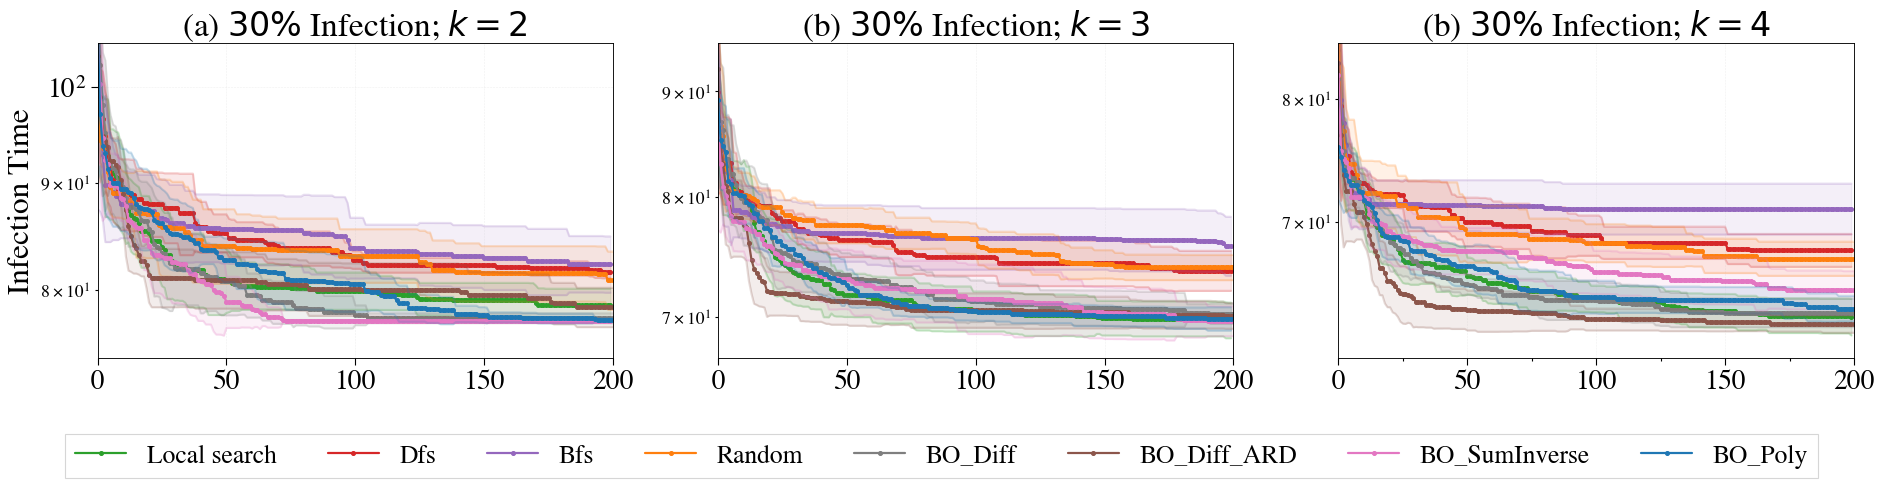

In [9]:
plot_contact(30,500)

plot_ba_ws()

#failtol_list = [10, 20, 30, 40]
#Q_list = [20, 50, 100, 200]

failtol_list = [30]
Q_list = [200]

input_data = list(product(failtol_list, Q_list))

with multiprocessing.Pool() as pool:
    #pool.starmap(plot_test, input_data)
    pool.starmap(plot_ba, input_data)
    #pool.starmap(plot_ws, input_data)

# Test Function